# 05 - Validação Estatística

**Projeto:** Análise do Mercado Imobiliário Português  
**Fase CRISP-DM:** Data Understanding / Data Preparation Validation  
**Objetivo:** validar estatisticamente relações relevantes antes da modelação, avaliando distribuição do preço, associações numéricas, diferenças entre grupos e multicolinearidade.  
**Última alteração:** 19/06/2026

Este notebook usa o dataset com features criado na fase 04. A validação estatística aqui feita é descritiva e inferencial exploratória: ajuda a orientar a modelação, mas não estabelece causalidade.

Entradas esperadas:
- `data/processed/portugal_listings_features.csv.gz`, versão recomendada para GitHub e Kaggle.
- `data/processed/portugal_listings_features.csv`, quando disponível localmente.
- Dataset anexado ao Kaggle em `/kaggle/input` ou ficheiro no GitHub.

Saídas esperadas:
- tabelas de validação estatística;
- gráficos guardados em `reports/figures/`, ou `/kaggle/working/figures/` em ambiente Kaggle;
- conclusões para orientar o baseline de modelação.

Nota metodológica:
- Com amostras grandes, valores-p tendem a ficar muito pequenos mesmo para efeitos modestos. Por isso, a interpretação deve considerar tamanho do efeito, robustez e relevância prática.


## Âmbito da Validação

Esta fase responde a quatro perguntas:

1. A variável `price` continua extremamente assimétrica depois da preparação?
2. Que variáveis numéricas apresentam associação mais forte com `log_price`?
3. Existem diferenças estatisticamente detetáveis entre grupos como `type`, `district` e `energy_certificate`?
4. Que variáveis numéricas podem introduzir redundância por multicolinearidade?

As respostas são usadas para orientar a modelação, não para afirmar relações causais.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

GITHUB_BASE_URL = "https://raw.githubusercontent.com/LuiscnFigueira/portugal-real-estate-market-analysis/main"
FEATURE_FILENAME = "portugal_listings_features.csv"
FEATURE_COMPRESSED_FILENAME = "portugal_listings_features.csv.gz"


def find_project_root(start=None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        markers = [candidate / "README.md", candidate / "requirements.txt", candidate / "data"]
        if all(marker.exists() for marker in markers):
            return candidate
    if Path("/kaggle/working").exists():
        return Path("/kaggle/working")
    return current


PROJECT_ROOT = find_project_root()
IS_KAGGLE = Path("/kaggle/working").exists()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

LOCAL_FEATURE_PATH = PROJECT_ROOT / "data" / "processed" / FEATURE_FILENAME
LOCAL_FEATURE_COMPRESSED_PATH = PROJECT_ROOT / "data" / "processed" / FEATURE_COMPRESSED_FILENAME
GITHUB_FEATURE_URL = f"{GITHUB_BASE_URL}/data/processed/{FEATURE_FILENAME}"
GITHUB_FEATURE_COMPRESSED_URL = f"{GITHUB_BASE_URL}/data/processed/{FEATURE_COMPRESSED_FILENAME}"

FIGURES_DIR = Path("/kaggle/working/figures") if IS_KAGGLE else PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raiz do projeto: {PROJECT_ROOT}")
print(f"Ambiente Kaggle: {IS_KAGGLE}")
print(f"Diretório de figuras: {FIGURES_DIR}")


Raiz do projeto: /kaggle/working
Ambiente Kaggle: True
Diretório de figuras: /kaggle/working/figures


## Funções Estatísticas

Sempre que `src.analysis.statistical_validation` estiver disponível, o notebook usa as funções reutilizáveis do projeto. Em ambiente Kaggle isolado, são definidas funções equivalentes de fallback.


In [2]:
try:
    from src.analysis.statistical_validation import (
        benjamini_hochberg,
        calculate_vif,
        group_distribution_summary,
        kruskal_group_test,
        numeric_association_summary,
        target_distribution_summary,
    )
    print("Funções carregadas a partir de src.analysis.statistical_validation")
except ModuleNotFoundError:
    print("Módulo src não encontrado. A usar funções locais de fallback.")
    from scipy import stats
    from sklearn.linear_model import LinearRegression

    def target_distribution_summary(df, target="price"):
        series = pd.to_numeric(df[target], errors="coerce").dropna()
        percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
        summary = {
            "count": series.count(), "mean": series.mean(), "std": series.std(),
            "min": series.min(), "skew": series.skew(), "kurtosis": series.kurtosis(),
            "max": series.max(),
        }
        summary.update({f"p{int(p * 100)}": series.quantile(p) for p in percentiles})
        return pd.DataFrame([summary]).T.rename(columns={0: target})

    def numeric_association_summary(df, target="log_price", columns=None, min_pairs=100):
        numeric_cols = columns or df.select_dtypes(include="number").columns.tolist()
        rows = []
        for col in numeric_cols:
            if col == target:
                continue
            pairs = df[[target, col]].apply(pd.to_numeric, errors="coerce").dropna()
            if len(pairs) < min_pairs:
                continue
            pearson_r, pearson_p = stats.pearsonr(pairs[col], pairs[target])
            spearman_r, spearman_p = stats.spearmanr(pairs[col], pairs[target])
            rows.append({
                "feature": col, "n_pairs": len(pairs),
                "pearson_r": pearson_r, "pearson_p": pearson_p,
                "spearman_r": spearman_r, "spearman_p": spearman_p,
                "abs_spearman_r": abs(spearman_r),
            })
        return pd.DataFrame(rows).sort_values("abs_spearman_r", ascending=False).reset_index(drop=True)

    def group_distribution_summary(df, category, target="log_price", min_group_size=100):
        data = df[[category, target]].dropna()
        counts = data[category].value_counts()
        valid = counts[counts >= min_group_size].index
        data = data[data[category].isin(valid)]
        return (
            data.groupby(category, observed=True)[target]
            .agg(n="count", mean="mean", median="median", std="std", q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
            .sort_values("median", ascending=False)
            .reset_index()
        )

    def kruskal_group_test(df, category, target="log_price", min_group_size=100):
        data = df[[category, target]].dropna()
        counts = data[category].value_counts()
        valid = counts[counts >= min_group_size].index
        data = data[data[category].isin(valid)]
        groups = [group[target].to_numpy() for _, group in data.groupby(category, observed=True)]
        if len(groups) < 2:
            return {"category": category, "groups": len(groups), "n": len(data), "h_statistic": np.nan, "p_value": np.nan, "epsilon_squared": np.nan}
        h, p = stats.kruskal(*groups)
        n = len(data)
        k = len(groups)
        eps = (h - k + 1) / (n - k) if n > k else np.nan
        return {"category": category, "groups": k, "n": n, "h_statistic": h, "p_value": p, "epsilon_squared": max(float(eps), 0.0)}

    def benjamini_hochberg(p_values):
        p_values = pd.to_numeric(p_values, errors="coerce")
        adjusted = pd.Series(np.nan, index=p_values.index, dtype="float64")
        valid = p_values.dropna().sort_values()
        n = len(valid)
        if n == 0:
            return adjusted
        ranked = valid * n / np.arange(1, n + 1)
        ranked = ranked.iloc[::-1].cummin().iloc[::-1].clip(upper=1)
        adjusted.loc[ranked.index] = ranked
        return adjusted

    def calculate_vif(df, columns, sample_size=50000, random_state=42):
        data = df[columns].apply(pd.to_numeric, errors="coerce")
        data = data.dropna(axis=1, how="all")
        data = data.fillna(data.median(numeric_only=True))
        data = data.replace([np.inf, -np.inf], np.nan).fillna(data.median(numeric_only=True))
        if len(data) > sample_size:
            data = data.sample(sample_size, random_state=random_state)
        rows = []
        usable = data.columns.tolist()
        for col in usable:
            other = [candidate for candidate in usable if candidate != col]
            if not other:
                continue
            model = LinearRegression()
            model.fit(data[other].to_numpy(), data[col].to_numpy())
            r2 = model.score(data[other].to_numpy(), data[col].to_numpy())
            vif = np.inf if r2 >= 0.999999 else 1 / (1 - r2)
            rows.append({"feature": col, "r2": r2, "vif": vif})
        return pd.DataFrame(rows).sort_values("vif", ascending=False).reset_index(drop=True)


Módulo src não encontrado. A usar funções locais de fallback.


## Carregamento do Dataset de Features

O notebook usa preferencialmente `portugal_listings_features.csv.gz`, porque é o artefacto recomendado para GitHub e Kaggle.


In [3]:
def kaggle_candidates(filename: str) -> list[Path]:
    base = Path("/kaggle/input")
    if not base.exists():
        return []
    return sorted(base.glob(f"**/{filename}"))


def read_first_available_csv(sources):
    errors = []
    for source in sources:
        if isinstance(source, Path) and not source.exists():
            continue
        try:
            return pd.read_csv(source, low_memory=False), source
        except Exception as exc:
            errors.append(f"{source}: {exc}")
    raise FileNotFoundError("Não foi possível carregar o dataset de features:" + "\n" + "\n".join(map(str, sources + errors)))


sources = [
    LOCAL_FEATURE_COMPRESSED_PATH,
    LOCAL_FEATURE_PATH,
    *kaggle_candidates(FEATURE_COMPRESSED_FILENAME),
    *kaggle_candidates(FEATURE_FILENAME),
    GITHUB_FEATURE_COMPRESSED_URL,
    GITHUB_FEATURE_URL,
]

df, data_source = read_first_available_csv(sources)

if "publish_date" in df.columns:
    df["publish_date"] = pd.to_datetime(df["publish_date"], errors="coerce")

print(f"Fonte usada: {data_source}")
print(f"Dataset de features: {df.shape[0]:,} linhas e {df.shape[1]:,} colunas")
display(df.head())


Fonte usada: https://raw.githubusercontent.com/LuiscnFigueira/portugal-real-estate-market-analysis/main/data/processed/portugal_listings_features.csv.gz
Dataset de features: 126,242 linhas e 71 colunas


,price,district,city,town,type,energy_certificate,gross_area,total_area,parking,has_parking,floor,construction_year,energy_efficiency_level,publish_date,garage,elevator,electric_cars_charging,total_rooms,number_of_bedrooms,number_of_wc,conservation_status,living_area,lot_size,built_area,number_of_bathrooms,price_m2,property_age,publish_year,publish_month,gross_area_missing,living_area_missing,lot_size_missing,built_area_missing,construction_year_missing,total_rooms_missing,number_of_bedrooms_missing,number_of_wc_missing,number_of_bathrooms_missing,energy_certificate_missing,conservation_status_missing,price_iqr_outlier,gross_area_iqr_outlier,total_area_iqr_outlier,living_area_iqr_outlier,lot_size_iqr_outlier,built_area_iqr_outlier,total_rooms_iqr_outlier,number_of_bathrooms_iqr_outlier,price_m2_iqr_outlier,log_price,log_total_area,log_living_area,log_gross_area,log_lot_size,log_built_area,living_total_area_ratio,gross_total_area_ratio,built_total_area_ratio,bedrooms_per_room,bathrooms_per_bedroom,rooms_per_bathroom,amenity_count,has_parking_or_garage,missing_core_feature_count,construction_decade,property_age_group,publish_quarter,publish_month_sin,publish_month_cos,district_type,city_type
0,"780,000.0000",Vila Real,Valpaços,Carrazedo de Montenegro e Curros,Farm,NC,200.0000,"552,450.0000",0.0000,False,NaN,NaN,NaN,NaT,NaN,False,NaN,NaN,NaN,NaN,NaN,120.0000,NaN,NaN,0.0000,1.4119,NaN,NaN,NaN,False,False,True,True,True,True,True,True,False,False,True,False,False,True,False,False,False,False,False,False,13.5671,13.2221,4.7958,5.3033,NaN,NaN,0.0002,0.0004,NaN,NaN,NaN,NaN,0,False,7,NaN,NaN,NaN,NaN,NaN,Vila Real__Farm,Valpaços__Farm
1,"223,000.0000",Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,81.0000,1.0000,True,Ground Floor,NaN,NaN,NaT,NaN,True,NaN,2.0000,NaN,NaN,NaN,81.0000,NaN,NaN,2.0000,"2,753.0864",NaN,NaN,NaN,True,False,True,True,True,False,True,True,False,False,True,False,False,False,False,False,False,False,False,False,12.3149,4.4067,4.4067,NaN,NaN,NaN,1.0000,NaN,NaN,NaN,NaN,1.0000,2,True,7,NaN,NaN,NaN,NaN,NaN,Faro__Apartment,São Brás de Alportel__Apartment
2,"228,000.0000",Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,108.0000,1.0000,True,Ground Floor,NaN,NaN,NaT,NaN,True,NaN,2.0000,NaN,NaN,NaN,108.0000,NaN,NaN,2.0000,"2,111.1111",NaN,NaN,NaN,True,False,True,True,True,False,True,True,False,False,True,False,False,False,False,False,False,False,False,False,12.3371,4.6913,4.6913,NaN,NaN,NaN,1.0000,NaN,NaN,NaN,NaN,1.0000,2,True,7,NaN,NaN,NaN,NaN,NaN,Faro__Apartment,São Brás de Alportel__Apartment
3,"250,000.0000",Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0000,1.0000,True,1st Floor,NaN,NaN,NaT,NaN,True,NaN,2.0000,NaN,NaN,NaN,114.0000,NaN,NaN,0.0000,"2,192.9825",NaN,NaN,NaN,True,False,True,True,True,False,True,True,False,False,True,False,False,False,False,False,False,False,False,False,12.4292,4.7449,4.7449,NaN,NaN,NaN,1.0000,NaN,NaN,NaN,NaN,NaN,2,True,7,NaN,NaN,NaN,NaN,NaN,Faro__Apartment,São Brás de Alportel__Apartment
4,"250,000.0000",Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0000,1.0000,True,2nd Floor,NaN,NaN,NaT,NaN,True,NaN,2.0000,NaN,NaN,NaN,114.0000,NaN,NaN,2.0000,"2,192.9825",NaN,NaN,NaN,True,False,True,True,True,False,True,True,False,False,True,False,False,False,False,False,False,False,False,False,12.4292,4.7449,4.7449,NaN,NaN,NaN,1.0000,NaN,NaN,NaN,NaN,1.0000,2,True,7,NaN,NaN,NaN,NaN,NaN,Faro__Apartment,São Brás de Alportel__Apartment


### Leitura dos resultados

A validação estatística usa o dataset com features da fase 04. Isto garante que as conclusões estatísticas estão alinhadas com a base que será usada para a modelação.


## Distribuição da Variável Alvo

A validação começa por comparar `price` e `log_price`. Em mercados imobiliários é comum que o preço tenha assimetria forte à direita, o que favorece estatísticas robustas e, muitas vezes, modelação com alvo transformado.


,price
count,"126,242.0000"
mean,"370,785.5593"
std,"3,935,294.7281"
min,1.0000
skew,341.3713
kurtosis,"119,660.4532"
max,"1,380,000,000.0000"
p1,"5,999.4100"
p5,"20,000.0000"
p25,"85,000.0000"


,log_price
count,"126,242.0000"
mean,12.1085
std,1.2367
min,0.6931
skew,-0.4770
kurtosis,0.8978
max,21.0453
p1,8.6996
p5,9.9035
p25,11.3504


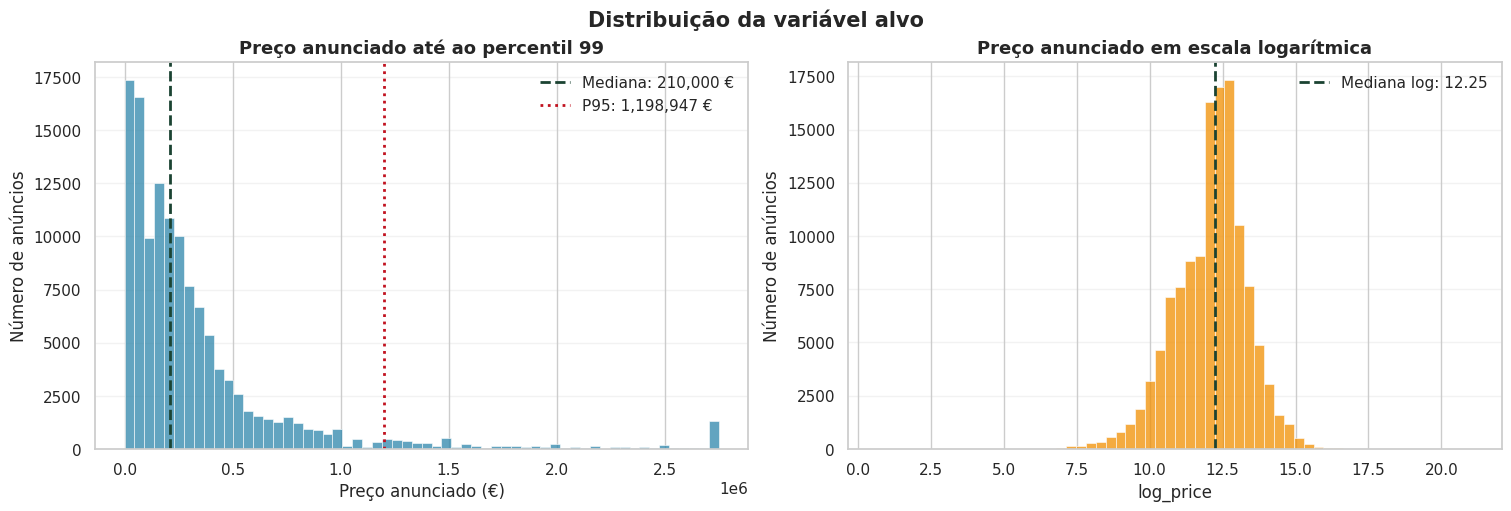

Figura guardada em: /kaggle/working/figures/05_price_distribution.png


In [4]:
price_summary = target_distribution_summary(df, target="price")
log_price_summary = target_distribution_summary(df, target="log_price") if "log_price" in df.columns else pd.DataFrame()

display(price_summary)
display(log_price_summary)

price = df["price"].dropna()
price_p99 = price.quantile(0.99)
price_plot = price.clip(upper=price_p99)
log_price = df["log_price"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

sns.histplot(price_plot, bins=60, ax=axes[0], color="#2E86AB", edgecolor="white", linewidth=0.4)
axes[0].axvline(price.median(), color="#1B4332", linestyle="--", linewidth=2, label=f"Mediana: {price.median():,.0f} €")
axes[0].axvline(price.quantile(0.95), color="#C1121F", linestyle=":", linewidth=2, label=f"P95: {price.quantile(0.95):,.0f} €")
axes[0].set_title("Preço anunciado até ao percentil 99", fontsize=13, weight="bold")
axes[0].set_xlabel("Preço anunciado (€)")
axes[0].set_ylabel("Número de anúncios")
axes[0].legend(frameon=False, loc="upper right")
axes[0].grid(axis="y", alpha=0.25)

sns.histplot(log_price, bins=60, ax=axes[1], color="#F18F01", edgecolor="white", linewidth=0.4)
axes[1].axvline(log_price.median(), color="#1B4332", linestyle="--", linewidth=2, label=f"Mediana log: {log_price.median():.2f}")
axes[1].set_title("Preço anunciado em escala logarítmica", fontsize=13, weight="bold")
axes[1].set_xlabel("log_price")
axes[1].set_ylabel("Número de anúncios")
axes[1].legend(frameon=False, loc="upper right")
axes[1].grid(axis="y", alpha=0.25)

fig.suptitle("Distribuição da variável alvo", fontsize=15, weight="bold")
fig_path = FIGURES_DIR / "05_price_distribution.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura guardada em: {fig_path}")


### Leitura dos resultados

A distribuição confirma que `price` é extremamente assimétrico, enquanto `log_price` é mais adequado para análise e modelação. Esta evidência justifica testar modelos com alvo transformado.


## Associações Numéricas

São calculadas correlações Pearson e Spearman com `log_price`. A correlação de Spearman é especialmente útil aqui porque é menos sensível a assimetria e relações não lineares monotónicas.


,feature,n_pairs,pearson_r,pearson_p,spearman_r,spearman_p,abs_spearman_r,pearson_p_adj,spearman_p_adj
0,number_of_bathrooms,119743,0.5041,0.0000,0.5939,0.0000,0.5939,0.0000,0.0000
1,amenity_count,126242,0.3869,0.0000,0.4461,0.0000,0.4461,0.0000,0.0000
2,number_of_bedrooms,43656,0.4243,0.0000,0.4346,0.0000,0.4346,0.0000,0.0000
3,total_rooms,68605,0.0850,0.0000,0.4298,0.0000,0.4298,0.0000,0.0000
4,bathrooms_per_bedroom,39320,0.1836,0.0000,0.4187,0.0000,0.4187,0.0000,0.0000
5,parking,126096,0.3217,0.0000,0.3774,0.0000,0.3774,0.0000,0.0000
6,construction_year,83118,0.3145,0.0000,0.3701,0.0000,0.3701,0.0000,0.0000
7,property_age,83118,-0.3145,0.0000,-0.3701,0.0000,0.3701,0.0000,0.0000
8,construction_decade,83118,0.3144,0.0000,0.3640,0.0000,0.3640,0.0000,0.0000
9,rooms_per_bathroom,59085,-0.2064,0.0000,-0.2972,0.0000,0.2972,0.0000,0.0000


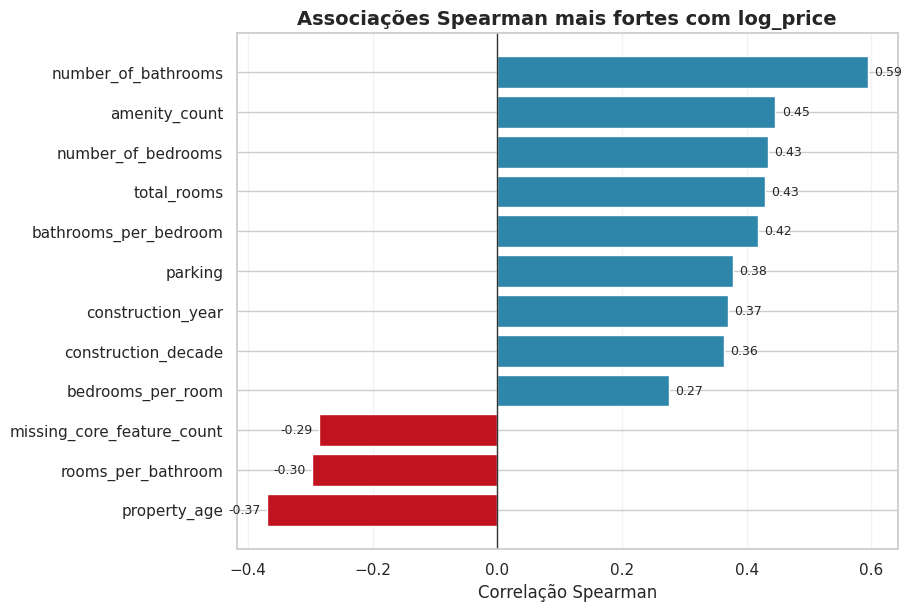

Figura guardada em: /kaggle/working/figures/05_top_spearman_correlations.png


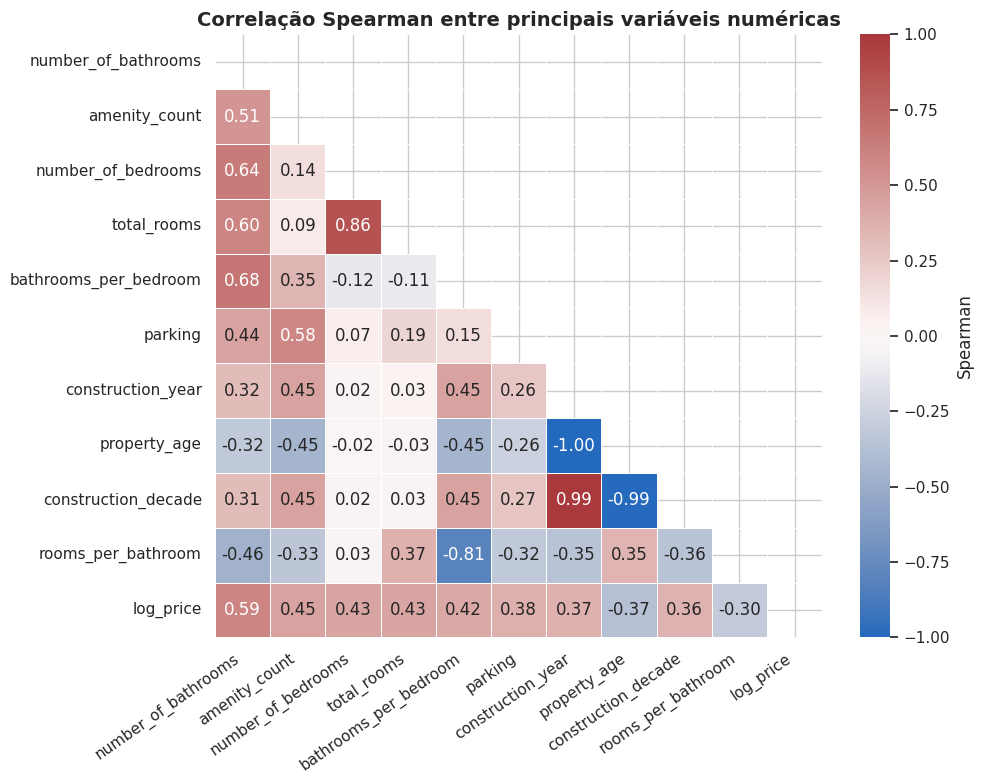

Figura guardada em: /kaggle/working/figures/05_spearman_correlation_heatmap.png


In [5]:
excluded_for_correlation = {
    "price", "log_price", "price_m2", "price_iqr_outlier", "price_m2_iqr_outlier",
}
numeric_columns = [
    col for col in df.select_dtypes(include="number").columns
    if col not in excluded_for_correlation and not col.endswith("_iqr_outlier")
]

correlation_summary = numeric_association_summary(
    df,
    target="log_price",
    columns=numeric_columns,
    min_pairs=1000,
)
correlation_summary["pearson_p_adj"] = benjamini_hochberg(correlation_summary["pearson_p"])
correlation_summary["spearman_p_adj"] = benjamini_hochberg(correlation_summary["spearman_p"])

display(correlation_summary.head(20))

top_corr = correlation_summary.head(12).copy().sort_values("spearman_r")
colors = ["#C1121F" if value < 0 else "#2E86AB" for value in top_corr["spearman_r"]]

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
ax.barh(top_corr["feature"], top_corr["spearman_r"], color=colors)
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Associações Spearman mais fortes com log_price", fontsize=14, weight="bold")
ax.set_xlabel("Correlação Spearman")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
for index, value in enumerate(top_corr["spearman_r"]):
    ha = "left" if value >= 0 else "right"
    offset = 0.01 if value >= 0 else -0.01
    ax.text(value + offset, index, f"{value:.2f}", va="center", ha=ha, fontsize=9)
fig_path = FIGURES_DIR / "05_top_spearman_correlations.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura guardada em: {fig_path}")

selected_corr_cols = correlation_summary.head(10)["feature"].tolist() + ["log_price"]
corr_matrix = df[selected_corr_cols].corr(method="spearman", numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Spearman"},
)
plt.title("Correlação Spearman entre principais variáveis numéricas", fontsize=14, weight="bold")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
fig_path = FIGURES_DIR / "05_spearman_correlation_heatmap.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura guardada em: {fig_path}")


### Leitura dos resultados

As associações mais fortes com `log_price` surgem em variáveis físicas e de amenidades, como casas de banho, quartos, divisões, estacionamento e idade do imóvel. Spearman é mais informativo do que Pearson quando há assimetria e relações monotónicas não lineares.


## Diferenças Entre Grupos

São avaliadas diferenças em `log_price` por variáveis categóricas. O teste de Kruskal-Wallis é usado por ser não paramétrico e mais adequado quando as distribuições são assimétricas.

A interpretação deve considerar `epsilon_squared` como tamanho de efeito aproximado. Com muitos registos, o valor-p tende a ser pequeno mesmo quando o efeito prático é modesto.


,category,groups,n,h_statistic,p_value,epsilon_squared,p_value_adj
0,type,14,125528,"32,252.9968",0.0000,0.2569,0.0000
2,energy_certificate,10,126170,"28,311.2472",0.0000,0.2243,0.0000
1,district,17,125755,"24,968.7060",0.0000,0.1984,0.0000
3,property_age_group,5,83118,"11,438.2094",0.0000,0.1376,0.0000


Resumo por type


,type,n,mean,median,std,q1,q3
0,Building,2392,13.1909,13.2177,0.9704,12.5425,13.8155
1,Industrial,399,13.0533,13.0990,1.2053,12.1678,13.7917
2,Duplex,363,13.2357,13.0711,0.7855,12.6761,13.7231
3,Apartment,43846,12.5622,12.5390,0.7868,12.1600,12.9420
4,Warehouse,1338,12.5797,12.5335,1.2343,11.7361,13.4412
5,Farm,3755,12.3243,12.4684,1.5258,11.2898,13.5022
6,House,34445,12.3267,12.4292,1.1306,11.5129,13.0711
7,Other - Commercial,762,12.3613,12.3458,1.3712,11.5922,13.3047
8,Office,695,12.1460,12.1007,1.1822,11.3022,12.8955
9,Store,5055,11.8262,11.7753,0.9858,11.2253,12.4252


Resumo por district


,district,n,mean,median,std,q1,q3
0,Lisboa,29883,12.7245,12.7628,1.0657,12.1495,13.4000
1,Faro,8010,12.2913,12.5947,1.5875,11.8465,13.2439
2,Setúbal,10817,12.5331,12.5172,0.8937,11.9829,13.0981
3,Porto,21114,12.3102,12.4589,1.0014,11.8422,12.8866
4,Braga,10551,11.9669,12.1281,0.9907,11.2898,12.6049
5,Aveiro,6832,11.8868,12.0375,1.0647,11.0898,12.6049
6,Évora,2281,11.9985,12.0137,1.1505,11.2772,12.6115
7,Beja,1261,11.9879,11.9184,1.1051,11.2385,12.6015
8,Leiria,6637,11.7010,11.8494,1.1755,10.9151,12.5245
9,Viana do Castelo,3339,11.5687,11.6953,1.2352,10.7144,12.4292


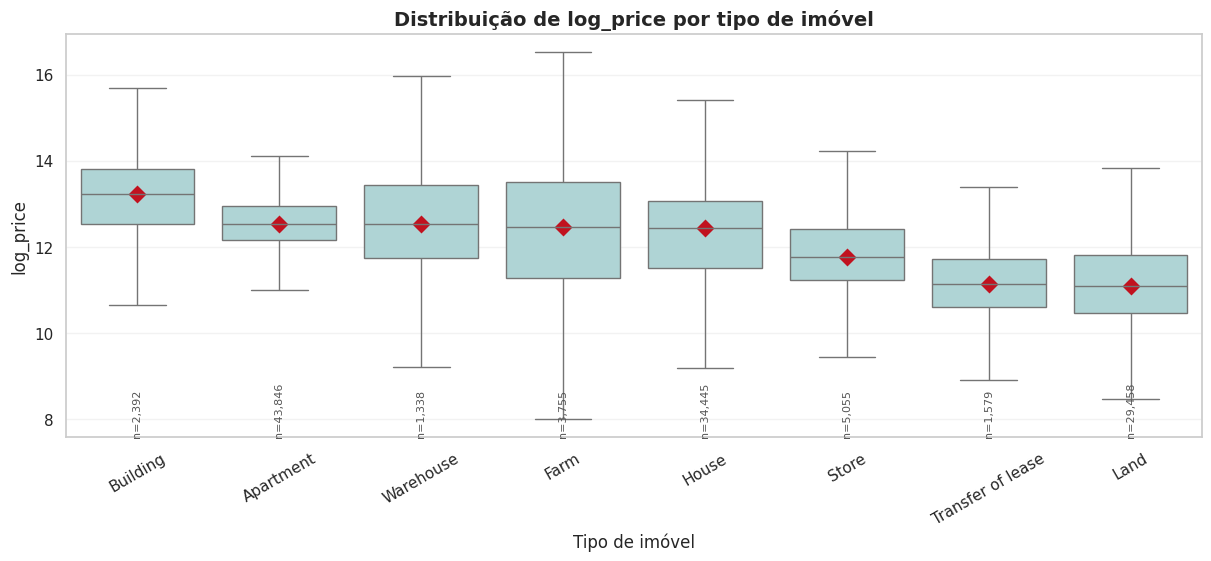

Figura guardada em: /kaggle/working/figures/05_log_price_by_type.png


In [6]:
categorical_tests = []
for category in ["type", "district", "energy_certificate", "property_age_group"]:
    if category in df.columns:
        categorical_tests.append(kruskal_group_test(df, category=category, target="log_price", min_group_size=300))

categorical_tests = pd.DataFrame(categorical_tests)
categorical_tests["p_value_adj"] = benjamini_hochberg(categorical_tests["p_value"])
display(categorical_tests.sort_values("epsilon_squared", ascending=False))

group_summaries = {}
for category in ["type", "district"]:
    if category in df.columns:
        group_summary = group_distribution_summary(df, category=category, target="log_price", min_group_size=300)
        group_summaries[category] = group_summary
        print(f"Resumo por {category}")
        display(group_summary.head(15))

top_types = df["type"].value_counts().head(8).index
type_order = (
    df[df["type"].isin(top_types)]
    .groupby("type", observed=True)["log_price"]
    .median()
    .sort_values(ascending=False)
    .index
)
fig_data = df[df["type"].isin(type_order)].copy()

fig, ax = plt.subplots(figsize=(12, 5.5), constrained_layout=True)
sns.boxplot(
    data=fig_data,
    x="type",
    y="log_price",
    order=type_order,
    showfliers=False,
    color="#A8DADC",
    linewidth=1,
    ax=ax,
)
sns.pointplot(
    data=fig_data,
    x="type",
    y="log_price",
    order=type_order,
    estimator="median",
    errorbar=None,
    color="#C1121F",
    markers="D",
    linestyles="",
    ax=ax,
)
ax.set_title("Distribuição de log_price por tipo de imóvel", fontsize=14, weight="bold")
ax.set_xlabel("Tipo de imóvel")
ax.set_ylabel("log_price")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.25)

counts = fig_data["type"].value_counts()
for tick, label in enumerate(type_order):
    ax.text(tick, ax.get_ylim()[0], f"n={counts[label]:,}", ha="center", va="bottom", fontsize=8, color="#555555", rotation=90)

fig_path = FIGURES_DIR / "05_log_price_by_type.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Figura guardada em: {fig_path}")


### Leitura dos resultados

Os testes por grupo indicam diferenças estatisticamente relevantes em `log_price` por tipologia, distrito, certificação energética e idade do imóvel. A interpretação deve focar tamanho de efeito e contexto, não apenas valores-p.


## Multicolinearidade

A multicolinearidade é avaliada com VIF em variáveis numéricas candidatas. Valores elevados sugerem redundância entre variáveis e podem destabilizar modelos lineares. Em modelos baseados em árvores, a preocupação é menor, mas ainda pode afetar interpretação.


In [7]:
vif_columns = [
    col for col in [
        "total_area", "living_area", "gross_area", "built_area", "lot_size",
        "log_total_area", "log_living_area", "log_gross_area", "log_built_area", "log_lot_size",
        "total_rooms", "number_of_bedrooms", "number_of_bathrooms",
        "living_total_area_ratio", "gross_total_area_ratio", "built_total_area_ratio",
        "bedrooms_per_room", "bathrooms_per_bedroom", "rooms_per_bathroom",
        "property_age", "amenity_count", "missing_core_feature_count",
    ]
    if col in df.columns
]

vif_summary = calculate_vif(df, columns=vif_columns, sample_size=50000, random_state=42)
display(vif_summary)


,feature,r2,vif
0,number_of_bathrooms,0.5475,2.2100
1,log_living_area,0.4863,1.9467
2,log_total_area,0.4377,1.7784
3,living_area,0.4315,1.7589
4,total_rooms,0.4136,1.7053
5,missing_core_feature_count,0.3510,1.5408
6,number_of_bedrooms,0.3398,1.5147
7,rooms_per_bathroom,0.3336,1.5006
8,gross_area,0.3143,1.4583
9,log_built_area,0.2762,1.3816


### Leitura dos resultados

Os valores de VIF não indicam multicolinearidade grave no conjunto testado. Ainda assim, áreas originais, versões logarítmicas e rácios podem representar informação semelhante, exigindo cautela em modelos lineares.


## Recomendações Para Modelação

A partir da validação estatística, as decisões seguintes devem ser aplicadas dentro de pipelines de treino:

- testar `log_price` como alvo transformado;
- excluir variáveis com leakage direto, como `price_m2`;
- controlar categorias raras antes do encoding;
- aplicar imputação e encoding apenas depois da separação treino/teste;
- avaliar modelos robustos a outliers e assimetria;
- interpretar valores-p com cautela devido ao tamanho da amostra.


In [8]:
outputs_dir = Path("/kaggle/working/statistical_outputs") if IS_KAGGLE else PROJECT_ROOT / "reports" / "statistical_outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

price_summary.to_csv(outputs_dir / "05_price_summary.csv")
correlation_summary.to_csv(outputs_dir / "05_numeric_correlations.csv", index=False)
categorical_tests.to_csv(outputs_dir / "05_categorical_tests.csv", index=False)
vif_summary.to_csv(outputs_dir / "05_vif_summary.csv", index=False)

print(f"Tabelas estatísticas guardadas em: {outputs_dir}")


Tabelas estatísticas guardadas em: /kaggle/working/statistical_outputs


### Leitura dos resultados

As tabelas estatísticas foram guardadas em `reports/statistical_outputs/`, permitindo consultar resultados fora do notebook e referenciá-los na documentação ou no relatório final.


## Conclusão

Esta validação confirma que o preço anunciado continua altamente assimétrico e que `log_price` é uma representação estatística mais adequada para análise e modelação futura.

Principais pontos a reter:
- as associações numéricas devem ser interpretadas sobretudo com Spearman e não apenas Pearson;
- variáveis de área, casas de banho, divisões, amenidades e localização apresentam sinais úteis para modelação;
- diferenças entre `type` e `district` são estatisticamente detetáveis, mas não devem ser interpretadas como causais;
- existe redundância esperada entre áreas e transformações logarítmicas, o que exige cuidado em modelos lineares;
- qualquer imputação, encoding ou tratamento estatístico aprendido deve ser ajustado apenas no conjunto de treino.

Artefactos produzidos:
- figuras em `reports/figures/`;
- tabelas em `reports/statistical_outputs/`;
- recomendações para o notebook de baseline de modelação.

Próxima etapa:
- criar `06_modeling_baseline.ipynb` com separação treino/teste, pipelines de imputação/encoding e modelos baseline locais.

**Última alteração:** 19/06/2026
